# Data Exploration
The objective of this motebook is:
- Verify the dataset loads correctly.
- Count images per class.
-Visualize a few examples.
- Understand image sizes.
- Prepare for the PyTorch pipeline.

## 0. Project Setup

In [1]:
from pathlib import Path

DATA_DIR = Path("../data/raw/train_images")

print(DATA_DIR.exists())

True


## 1. Imports

In [2]:
import pandas as pd
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt

## 2. Count Classes

In [3]:
classes = sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()])

print(classes)
print(f"Number of classes: {len(classes)}")

['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']
Number of classes: 10


## 3. Count images in each class

In [4]:
counts = {}

for cls in classes:
    counts[cls] = len(list((DATA_DIR / cls).glob("*.jpg")))

counts

{'bacterial_leaf_blight': 479,
 'bacterial_leaf_streak': 380,
 'bacterial_panicle_blight': 337,
 'blast': 1738,
 'brown_spot': 965,
 'dead_heart': 1442,
 'downy_mildew': 620,
 'hispa': 1594,
 'normal': 1764,
 'tungro': 1088}

In [5]:
pd.DataFrame.from_dict(
    counts,
    orient="index",
    columns=["num_images"]
).sort_values("num_images", ascending=False)

,num_images
normal,1764
blast,1738
hispa,1594
dead_heart,1442
tungro,1088
brown_spot,965
downy_mildew,620
bacterial_leaf_blight,479
bacterial_leaf_streak,380
bacterial_panicle_blight,337


## 4. Load Sample Images

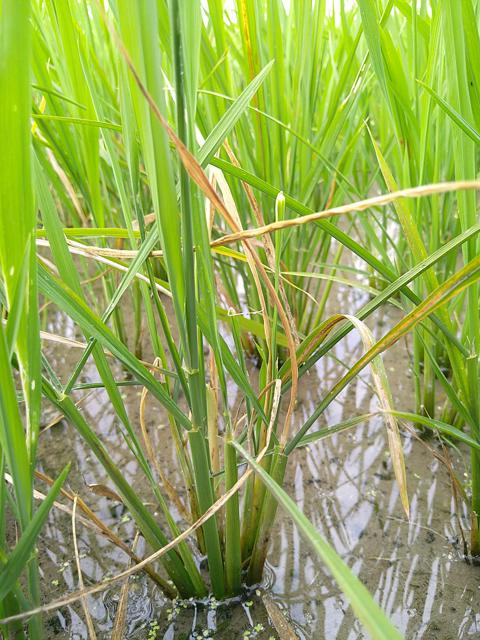

In [6]:
sample_path = next((DATA_DIR / "blast").glob("*.jpg"))

img = Image.open(sample_path)

img

In [7]:
img.size

(480, 640)

## 5. Display Some Examples

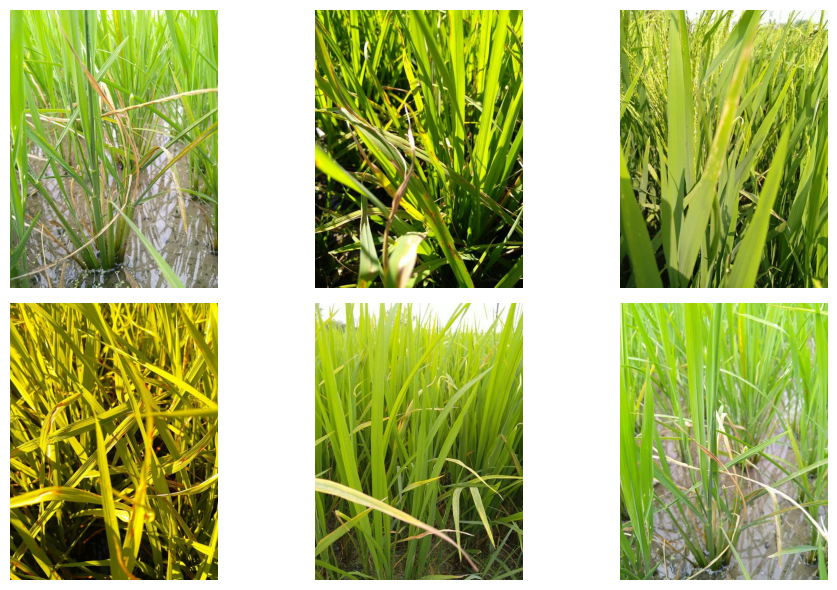

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

paths = list((DATA_DIR / "blast").glob("*.jpg"))[:6]

for ax, path in zip(axes.flatten(), paths):
    img = Image.open(path)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()